# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset: CO2_Data

Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load the dataset
df = pd.read_csv('co2_data.csv')

# Display the first 5 rows to ensure the data loaded correctly
df.head()

,Description,Name,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Country,Afghanistan,1850,AFG,3752993.0,NaN,0.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.436,0.629,NaN,NaN
1,Country,Afghanistan,1851,AFG,3767956.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.156,0.0,0.0,0.0,0.0,7.500,0.633,NaN,NaN
2,Country,Afghanistan,1852,AFG,3783940.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.155,0.0,0.0,0.0,0.0,7.560,0.637,NaN,NaN
3,Country,Afghanistan,1853,AFG,3800954.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.155,0.0,0.0,0.0,0.0,7.620,0.641,NaN,NaN
4,Country,Afghanistan,1854,AFG,3818038.0,NaN,0.0,0.0,NaN,NaN,...,NaN,0.155,0.0,0.0,0.0,0.0,7.678,0.644,NaN,NaN


## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

In [11]:
# Manual Column Assignment
country_col = 'Name'
year_col = 'year'
co2_col = 'co2'

# Also looking at GDP and Population
print(f"Primary Columns: Entity='{country_col}', Year='{year_col}', CO2='{co2_col}'")
print("-" * 30)

# Structural Overview
# Checking the shape to see total rows and columns
print(f"Dataset Shape: {df.shape}")

# df.info() shows us data types (int, float, object)
print("\nColumn Information & Data Types:")
df.info()

# Exploring the Data Range
# Understanding how many countries are included and the timeframe
unique_entities = df[country_col].nunique()
year_min = df[year_col].min()
year_max = df[year_col].max()

print(f"\nUnique Entities/Regions: {unique_entities}")
print(f"Timeframe: {year_min} to {year_max}")

# Statistical Summary
# Using .describe() on specific columns to see the distribution of values
print(f"\nStatistical Summary:")
cols_to_describe = [co2_col, 'gdp', 'population']
print(df[cols_to_describe].describe())

# Missing Values Check
# CO2 datasets often have many missing values for historical GDP or specific gases
null_counts = df.isnull().sum()
print("\nTop 10 Columns with Missing Values (Nulls):")
print(null_counts.sort_values(ascending=False).head(10))

# Sorting for Context 
# Looking at the highest 'co2' values helps identify if 'World' or regions are rows
print("\nTop 5 Highest CO2 Emission Records (Historical):")
print(df.sort_values(by=co2_col, ascending=False)[[country_col, year_col, co2_col]].head())

Primary Columns: Entity='Name', Year='year', CO2='co2'
------------------------------
Dataset Shape: (43746, 80)

Column Information & Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43746 entries, 0 to 43745
Data columns (total 80 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Description                                43746 non-null  object 
 1   Name                                       43746 non-null  object 
 2   year                                       43746 non-null  int64  
 3   iso_code                                   37921 non-null  object 
 4   population                                 37965 non-null  float64
 5   gdp                                        14989 non-null  float64
 6   cement_co2                                 23612 non-null  float64
 7   cement_co2_per_capita                      22715 non-null  float64
 8   co2                

## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.

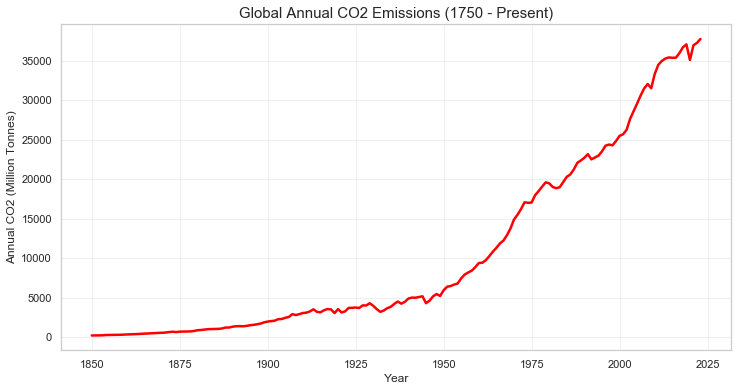

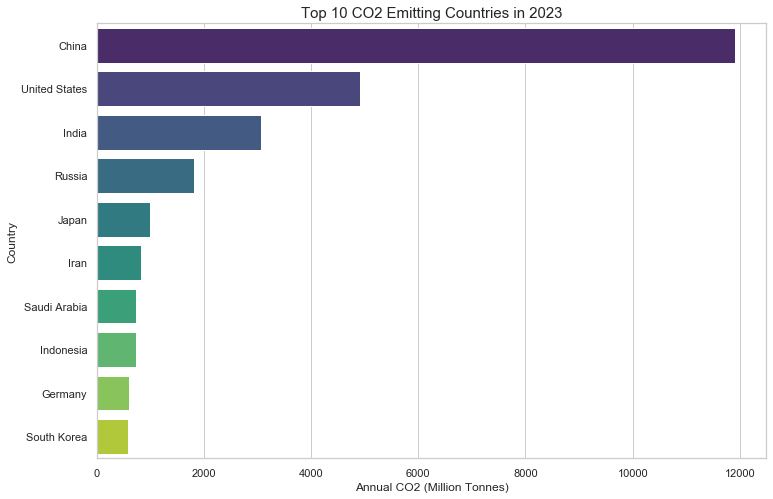

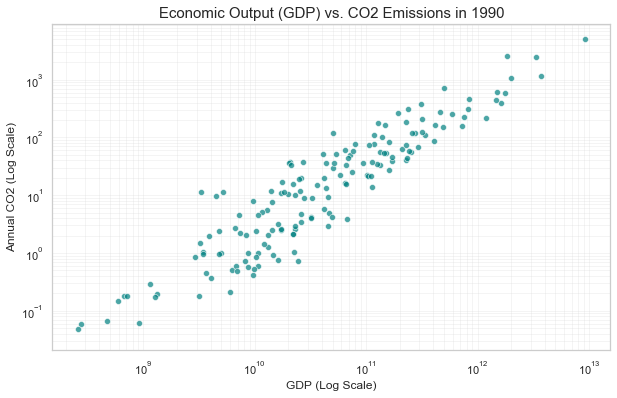

In [16]:
#  Global CO2 Trend Over Time 
# Thought Process: I want to see the total human impact from 1750 to present. 
# Using the 'World' entity allows us to see the global sum without manual calculation.

plt.figure(figsize=(12, 6))

# Filtering for the 'World' entity
world_data = df[df['Name'] == 'World']

sns.lineplot(data=world_data, x='year', y='co2', color='red', linewidth=2.5)

plt.title('Global Annual CO2 Emissions (1750 - Present)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Annual CO2 (Million Tonnes)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Top 10 Emitters in the Most Recent Year 
# Thought Process: To compare countries fairly, I must filter out regional aggregates.
# I'll use the 'iso_code' column to ensure I only pull individual nations.

plt.figure(figsize=(12, 8))

# Find the most recent year and filter for real countries only
latest_year = df['year'].max()
current_countries = df[(df['year'] == latest_year) & 
                       (df['iso_code'].notnull()) & 
                       (df['Name'] != 'World')]

# Sort and grab top 10
top_10 = current_countries.sort_values(by='co2', ascending=False).head(10)

# Creating the bar plot
sns.barplot(data=top_10, x='co2', y='Name', palette='viridis')

plt.title(f'Top 10 CO2 Emitting Countries in {latest_year}', fontsize=15)
plt.xlabel('Annual CO2 (Million Tonnes)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()

# CO2 vs GDP Correlation 
# Thought Process: Since GDP data is missing for 2023, I am using 1990 
# (the year with the most complete records) to show the economic relationship.

# Using 1990 as identified by our diagnostic
plot_year = 1990

# Filter for the year 1990, real countries only, and drop missing values
gdp_plot_data = df[(df['year'] == plot_year) & 
                   (df['iso_code'].notnull()) & 
                   (df['Name'] != 'World')].dropna(subset=['gdp', 'co2'])

plt.figure(figsize=(10, 6))

# Creating the scatter plot
sns.scatterplot(data=gdp_plot_data, x='gdp', y='co2', alpha=0.7, color='teal')

# Set titles and labels
plt.title(f'Economic Output (GDP) vs. CO2 Emissions in {plot_year}', fontsize=15)
plt.xlabel('GDP (Log Scale)', fontsize=12)
plt.ylabel('Annual CO2 (Log Scale)', fontsize=12)

plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

## Summarize Your Results

With your EDA complete, answer the following questions.

1. Was there anything surprising about your dataset? 

The most surprising thing was how the data is mixed together. It doesn’t just list countries; it also includes giant groups like "World" and "High-income countries." Because these groups add up the emissions of dozens of nations, their numbers are huge. If you aren't careful, "World" looks like the biggest "country" on your charts.

I also found it interesting that we have very recent pollution data (up to 2023), but the economic data (like GDP) is quite old and hasn't been updated as quickly.

2. Do you have any concerns about your dataset? 

There is a big "hole" in the data where many countries have CO₂ numbers but are missing their GDP or Population numbers for recent years. It is hard to compare a small island to a huge country like China just by looking at total numbers. I'll need to be careful to explain that "most emissions" doesn't always mean "least efficient."

3. Is there anything you want to make note of for the next phase of your analysis, which is cleaning data? 

Filter: Create a "Countries Only" list so that regions like "World" or "Africa" don't mess up my country rankings.
Pick a Year: Since 1990 has the most complete info for both money (GDP) and pollution, I will use that year when I want to compare the two.